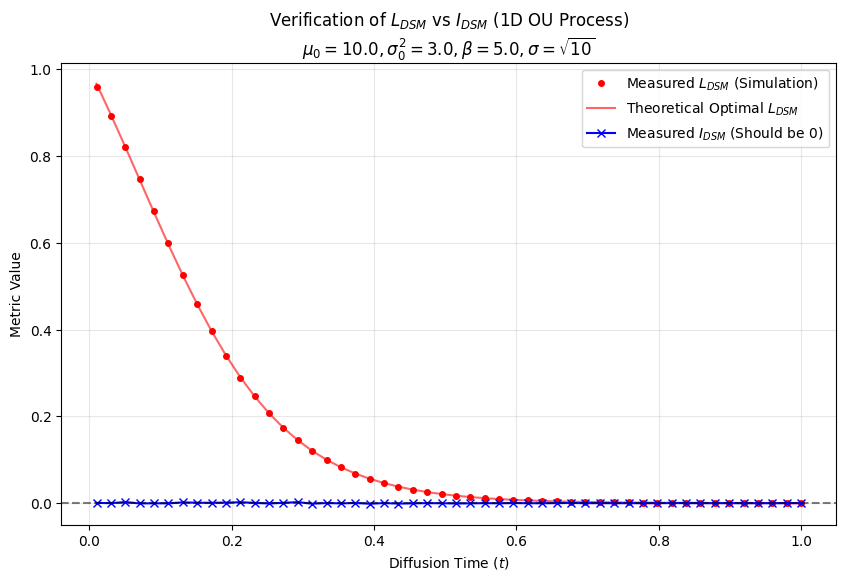

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 參數設定 (與手算一致)
mu_0 = 10.0
var_0 = 3.0
beta = 5.0
sigma_q = np.sqrt(10.0)  # 雜訊強度 sigma
n_samples = 100000       # 使用大量樣本來減少隨機誤差

# 時間點設定 (從接近 0 到 T =1.0)
t_steps = np.linspace(0.01, 1.0, 50)
ldsm_history = []
idsm_history = []
theoretical_ldsm = []

for t in t_steps:
    # --- 擴散過程係數 ---
    a_t = np.exp(-beta * t)  #<< mu_t
    # s_t 為雜訊的標準差係數
    s_t = np.sqrt((sigma_q**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t)))
    
    # --- 採樣 ---
    x0 = np.random.normal(mu_0, np.sqrt(var_0), n_samples)
    eps = np.random.normal(0, 1, n_samples)
    xt = a_t * x0 + s_t * eps
    
    # --- 理論最優預測 (Exact Solution) ---
    # 根據我們手算的公式: eps_star = Cov(eps, xt)/Var(xt) * (xt - E[xt])
    var_xt = var_0 * (a_t**2) + s_t**2
    cov_eps_xt = s_t
    mean_xt = mu_0 * a_t
    
    eps_theta = (cov_eps_xt / var_xt) * (xt - mean_xt)
    
    # --- Indicators ---
    # L_DSM = E[(eps_theta - eps)^2]
    l_dsm = np.mean((eps_theta - eps)**2)
    # I_DSM = E[eps_theta * (eps_theta - eps)]
    i_dsm = np.mean(eps_theta * (eps_theta - eps))
    
    # --- 理論預期值 (用來對照) ---
    # 理論 L_DSM = 1 - (s_t^2 / var_xt)
    l_theory = 1 - (s_t**2 / var_xt)
    
    ldsm_history.append(l_dsm)
    idsm_history.append(i_dsm)
    theoretical_ldsm.append(l_theory)

# 2. 繪圖證明
plt.figure(figsize=(10, 6))
plt.plot(t_steps, ldsm_history, 'ro', label='Measured $L_{DSM}$ (Simulation)', markersize=4)
plt.plot(t_steps, theoretical_ldsm, 'r-', label='Theoretical Optimal $L_{DSM}$', alpha=0.6)
plt.plot(t_steps, idsm_history, 'b-x', label='Measured $I_{DSM}$ (Should be 0)')

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title(f'Verification of $L_{{DSM}}$ vs $I_{{DSM}}$ (1D OU Process)\n'
          f'$\mu_0={mu_0}, \sigma^2_0={var_0}, \\beta={beta}, \sigma=\sqrt{{10}}$')
plt.xlabel('Diffusion Time ($t$)')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


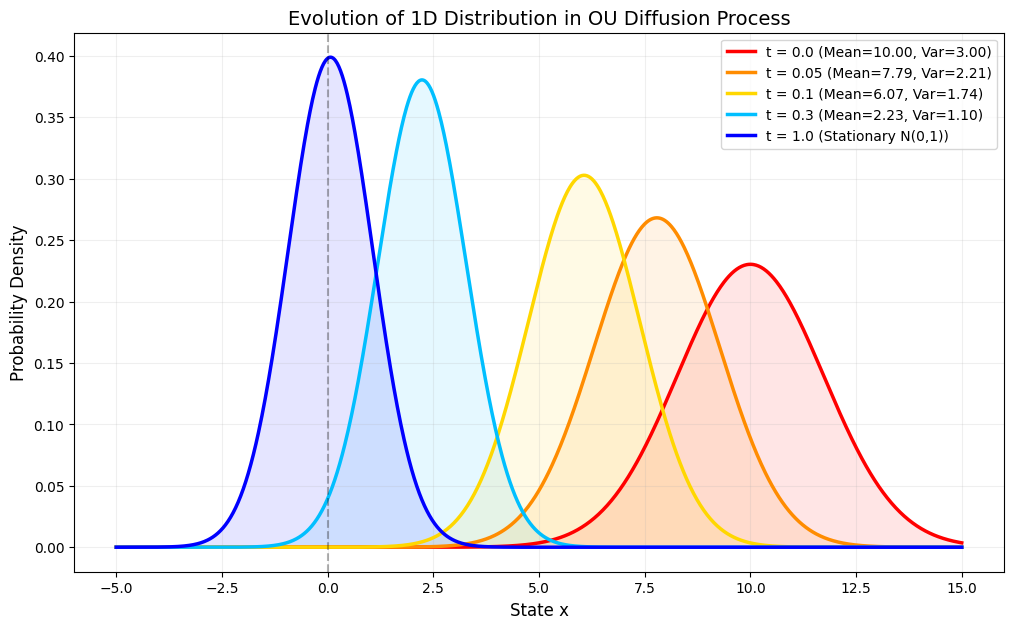

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 參數設定
mu_0 = 10.0
var_0 = 3.0
beta = 5.0
sigma_q = np.sqrt(2*beta)

# 選取 5 個時間階段
t_points = [0.0, 0.05, 0.1, 0.3, 1.0]
colors = ['#FF0000', '#FF8C00', '#FFD700', '#00BFFF', '#0000FF'] # 紅到藍

x_axis = np.linspace(-5, 15, 1000)
plt.figure(figsize=(12, 7))

for t, color in zip(t_points, colors):
    # OU 過程解析解的均值與變異數
    a_t = np.exp(-beta * t)
    s_t_sq = (sigma_q**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
    
    current_mu = mu_0 * a_t
    current_var = var_0 * (a_t**2) + s_t_sq
    current_std = np.sqrt(current_var)
    
    # 畫出 PDF
    y = norm.pdf(x_axis, current_mu, current_std)
    label = f't = {t} (Mean={current_mu:.2f}, Var={current_var:.2f})'
    if t == 1.0: label = f't = {t} (Stationary N(0,1))'
    
    plt.plot(x_axis, y, label=label, color=color, lw=2.5)
    plt.fill_between(x_axis, y, alpha=0.1, color=color)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.title('Evolution of 1D Distribution in OU Diffusion Process', fontsize=14)
plt.xlabel('State x', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 看這個


==================== Experiment: Sigma = 1.000 ====================
Time (t)   | Mean_xt    | Var_xt     | L_DSM (Opt)  | I_DSM (Opt) 
-----------------------------------------------------------------
0.00       | 10.00      | 3.00       | 0.998081     | 0.000000    
0.05       | 7.79       | 1.86       | 0.981351     | 0.000120    
0.10       | 6.07       | 1.17       | 0.945244     | 0.000459    
0.30       | 2.23       | 0.24       | 0.608766     | 0.000570    
1.00       | 0.07       | 0.10       | 0.001362     | -0.000037   


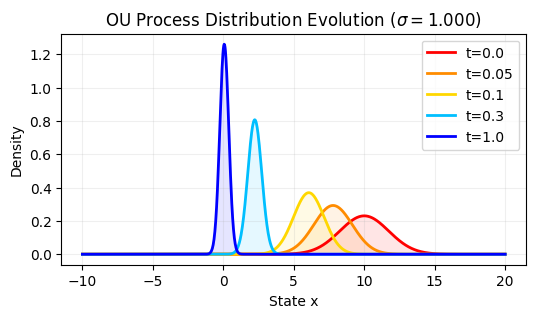


==================== Experiment: Sigma = 2.000 ====================
Time (t)   | Mean_xt    | Var_xt     | L_DSM (Opt)  | I_DSM (Opt) 
-----------------------------------------------------------------
0.00       | 10.00      | 3.00       | 1.001800     | 0.000000    
0.05       | 7.79       | 1.98       | 0.920648     | -0.000114   
0.10       | 6.07       | 1.36       | 0.814108     | -0.000236   
0.30       | 2.23       | 0.53       | 0.282088     | 0.001010    
1.00       | 0.07       | 0.40       | 0.000341     | 0.000014    


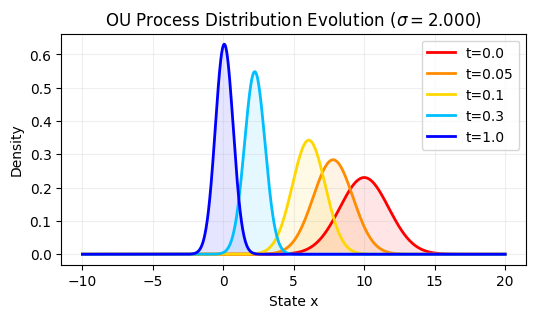


==================== Experiment: Sigma = 3.162 ====================
Time (t)   | Mean_xt    | Var_xt     | L_DSM (Opt)  | I_DSM (Opt) 
-----------------------------------------------------------------
0.00       | 10.00      | 3.00       | 0.995722     | 0.000000    
0.05       | 7.79       | 2.21       | 0.823818     | 0.000628    
0.10       | 6.07       | 1.74       | 0.634923     | 0.000732    
0.30       | 2.23       | 1.10       | 0.135980     | 0.000057    
1.00       | 0.07       | 1.00       | 0.000136     | 0.000024    


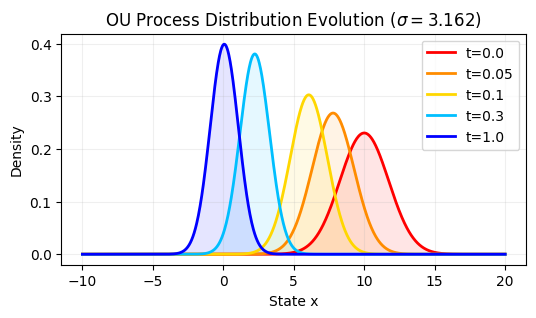


==================== Experiment: Sigma = 5.000 ====================
Time (t)   | Mean_xt    | Var_xt     | L_DSM (Opt)  | I_DSM (Opt) 
-----------------------------------------------------------------
0.00       | 10.00      | 3.00       | 1.001541     | 0.000000    
0.05       | 7.79       | 2.80       | 0.649054     | -0.001956   
0.10       | 6.07       | 2.68       | 0.411570     | -0.000093   
0.30       | 2.23       | 2.52       | 0.059279     | 0.000101    
1.00       | 0.07       | 2.50       | 0.000054     | 0.000011    


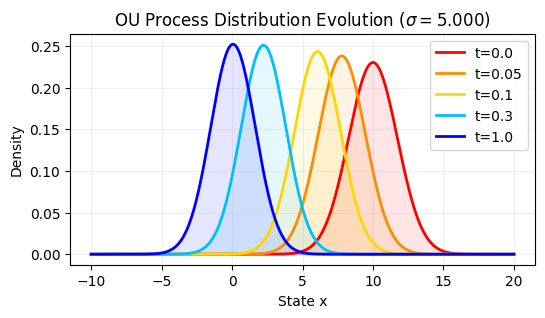


==================== Experiment: Sigma = 7.000 ====================
Time (t)   | Mean_xt    | Var_xt     | L_DSM (Opt)  | I_DSM (Opt) 
-----------------------------------------------------------------
0.00       | 10.00      | 3.00       | 1.000466     | 0.000000    
0.05       | 7.79       | 3.75       | 0.485659     | 0.000310    
0.10       | 6.07       | 4.20       | 0.262980     | 0.000179    
0.30       | 2.23       | 4.81       | 0.031133     | 0.000173    
1.00       | 0.07       | 4.90       | 0.000028     | 0.000005    


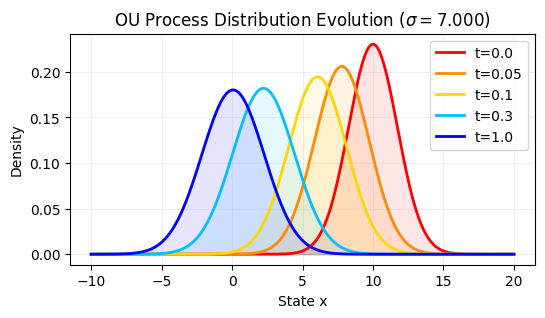

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 基礎參數設定
mu_0 = 10.0
var_0 = 3.0
beta = 5.0
n_samples = 500000
t_points = [0.0, 0.05, 0.1, 0.3, 1.0]
sigma_list = [1.0, 2.0, np.sqrt(10), 5.0, 7.0]
colors = ['#FF0000', '#FF8C00', '#FFD700', '#00BFFF', '#0000FF']

# 2. 開始生成 5 種 Sigma 的實驗結果
for sig in sigma_list:
    sigma_val = float(sig)
    print(f"\n{'='*20} Experiment: Sigma = {sigma_val:.3f} {'='*20}")
    print(f"{'Time (t)':<10} | {'Mean_xt':<10} | {'Var_xt':<10} | {'L_DSM (Opt)':<12} | {'I_DSM (Opt)':<12}")
    print("-" * 65)
    
    plt.figure(figsize=(6, 3))
    x_axis = np.linspace(-10, 20, 1000)
    
    for t, color in zip(t_points, colors):
        # --- 擴散過程係數 ---
        a_t = np.exp(-beta * t)
        # 注意：s_t_sq 受 sigma 影響
        s_t_sq = (sigma_val**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
        s_t = np.sqrt(s_t_sq)
        
        # --- 理論統計量 ---
        mean_xt = mu_0 * a_t
        var_xt = var_0 * (a_t**2) + s_t_sq
        
        # --- 模擬採樣 ---
        x0_s = np.random.normal(mu_0, np.sqrt(var_0), n_samples)
        eps_s = np.random.normal(0, 1, n_samples)
        xt_s = a_t * x0_s + s_t * eps_s
        
        # --- 代入當前 Sigma 下的最優解析解 ---
        # eps_theta = E[eps|xt]
        eps_theta = (s_t / var_xt) * (xt_s - mean_xt)
        
        # --- 計算指標 ---
        l_dsm = np.mean((eps_theta - eps_s)**2)
        i_dsm = np.mean(eps_theta * (eps_theta - eps_s))
        
        # --- 輸出表格數據 ---
        print(f"{t:<10.2f} | {mean_xt:<10.2f} | {var_xt:<10.2f} | {l_dsm:<12.6f} | {i_dsm:<12.6f}")
        
        # --- 繪製 PDF ---
        y = norm.pdf(x_axis, mean_xt, np.sqrt(var_xt))
        plt.plot(x_axis, y, label=f't={t}', color=color, lw=2)
        plt.fill_between(x_axis, y, alpha=0.1, color=color)

    plt.title(f'OU Process Distribution Evolution ($\sigma = {sigma_val:.3f}$)')
    plt.xlabel('State x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
